# Линейная регрессия

Бабошин Никита Андреевич (6401-010203D)

## Считать в `pandas.DataFrame` любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.

> Датасет должен содержать как минимум количественные признаки. Если категориальных нет, то пропустить пункты с временным убиранием категориальных признаков. Желательно наличие обоих типов признаков в датасете.

In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
  
# fetch dataset 
auto_mpg = fetch_ucirepo(id=9) 
  
# data (as pandas dataframes) 
X = auto_mpg.data.features 
y = auto_mpg.data.targets 

# variable information 
auto_mpg.variables

,name,role,type,demographic,description,units,missing_values
0,displacement,Feature,Continuous,None,None,None,no
1,mpg,Target,Continuous,None,None,None,no
2,cylinders,Feature,Integer,None,None,None,no
3,horsepower,Feature,Continuous,None,None,None,yes
4,weight,Feature,Continuous,None,None,None,no
5,acceleration,Feature,Continuous,None,None,None,no
6,model_year,Feature,Integer,None,None,None,no
7,origin,Feature,Integer,None,None,None,no
8,car_name,ID,Categorical,None,None,None,no


## Датасет и подготовка данных, этап 1

### Привести описание датасета

Ссылка: https://archive.ics.uci.edu/dataset/9/auto+mpg 

Датасет содержит данные о технических характеристиках автомобилей, цель (целевой признак, таргет) — прогнозирование расхода топлива в городском цикле (`mpg`).

| Признак | Описание | Единицы измерения |
| --- | --- | --- |
| **mpg** | **Эффективность расхода топлива (целевая переменная)** | миль на галлон (mpg) |
| cylinders | Количество цилиндров двигателя | шт. |
| displacement | Рабочий объём двигателя | куб. дюймы (cu. in.) |
| horsepower | Мощность двигателя | л.с. (hp) |
| weight | Снаряженная масса автомобиля | фунты (lbs) |
| acceleration | Время разгона от 0 до 60 миль/ч | секунды |
| model_year | Год выпуска модели (двузначный формат, например, 70 = 1970) | год (1970–1982) |
| origin | Код региона производства: 1=USA, 2=Europe, 3=Japan, 4=Other | категориальный код |
| car_name | Полное название модели автомобиля (уникальный идентификатор) | — |

In [2]:
X.head()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1


In [3]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 21.9 KB


### Осуществить предобработку данных (избавиться от `null`, убрать некоторые признаки и т.п.) &ndash; "подчистить данные"

Заполнение пропусков в horsepower (медианой, т.к. возможны выбросы)

In [4]:
X['horsepower'] = X['horsepower'].fillna(X['horsepower'].median())

### Нормализовать численные данные

In [5]:
from sklearn.preprocessing import MinMaxScaler

features_no_cat = ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year']

scaler = MinMaxScaler()
X[features_no_cat] = scaler.fit_transform(X[features_no_cat])

X[features_no_cat].describe()

,displacement,cylinders,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,0.324098,0.490955,0.316870,0.384867,0.450482,0.500838
std,0.269431,0.340201,0.207732,0.240103,0.164148,0.308136
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.093669,0.200000,0.163043,0.173164,0.346726,0.250000
50%,0.208010,0.200000,0.258152,0.337539,0.446429,0.500000
75%,0.501292,1.000000,0.429348,0.565637,0.546131,0.750000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Визуализировать `heatmap`-матрицу коррелированности признаков

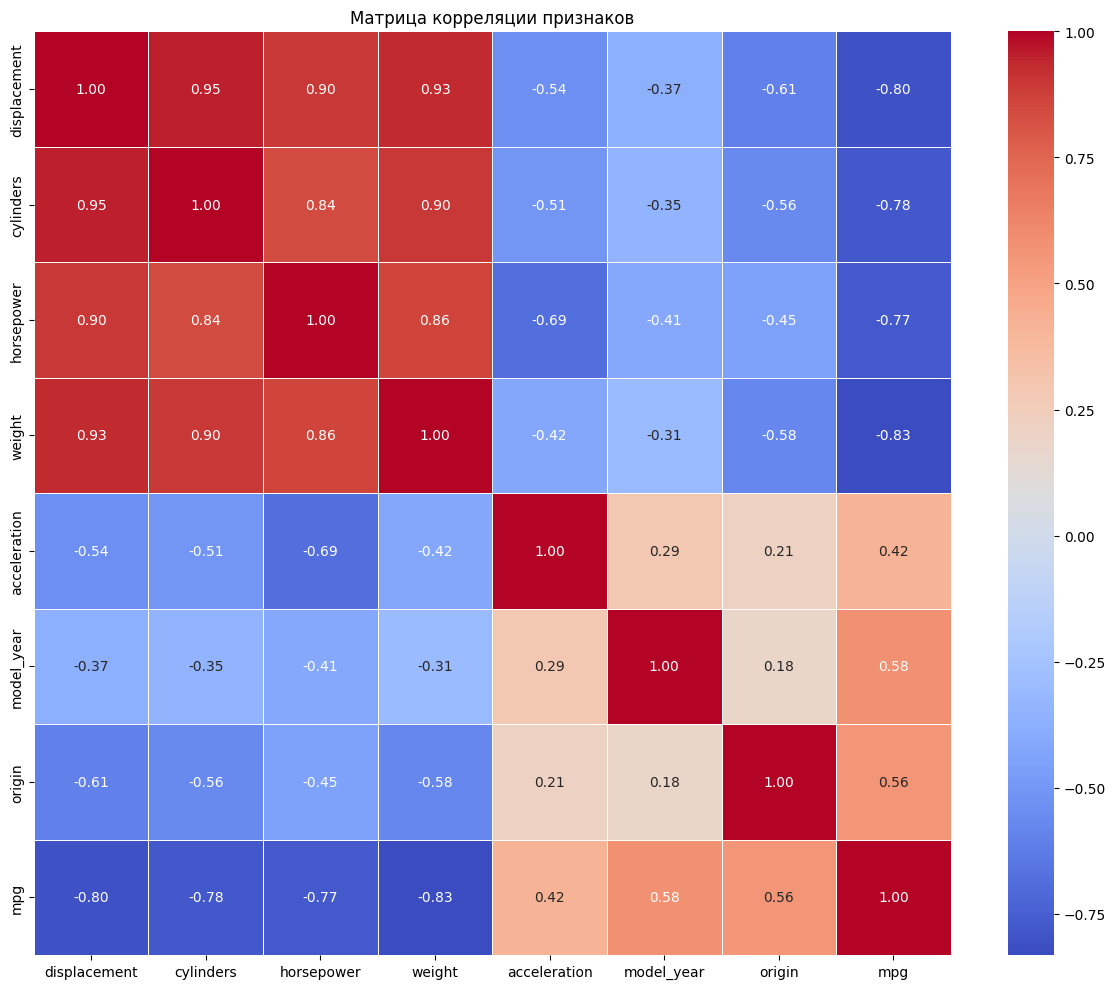

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.concat([X, y], axis=1)
corr_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции признаков')
plt.tight_layout()
plt.show()

### Визуализировать взаимосвязь между `target`-переменной и каждым из признаков 

(с использованием `srs.pairplot` или `pandas.plotting.scatter_matrix`). Лучше всего построить диаграмму попарного распределения между таргетом и каждым из признаков отдельно (пример с `sns.FacetGrid` в лекции).

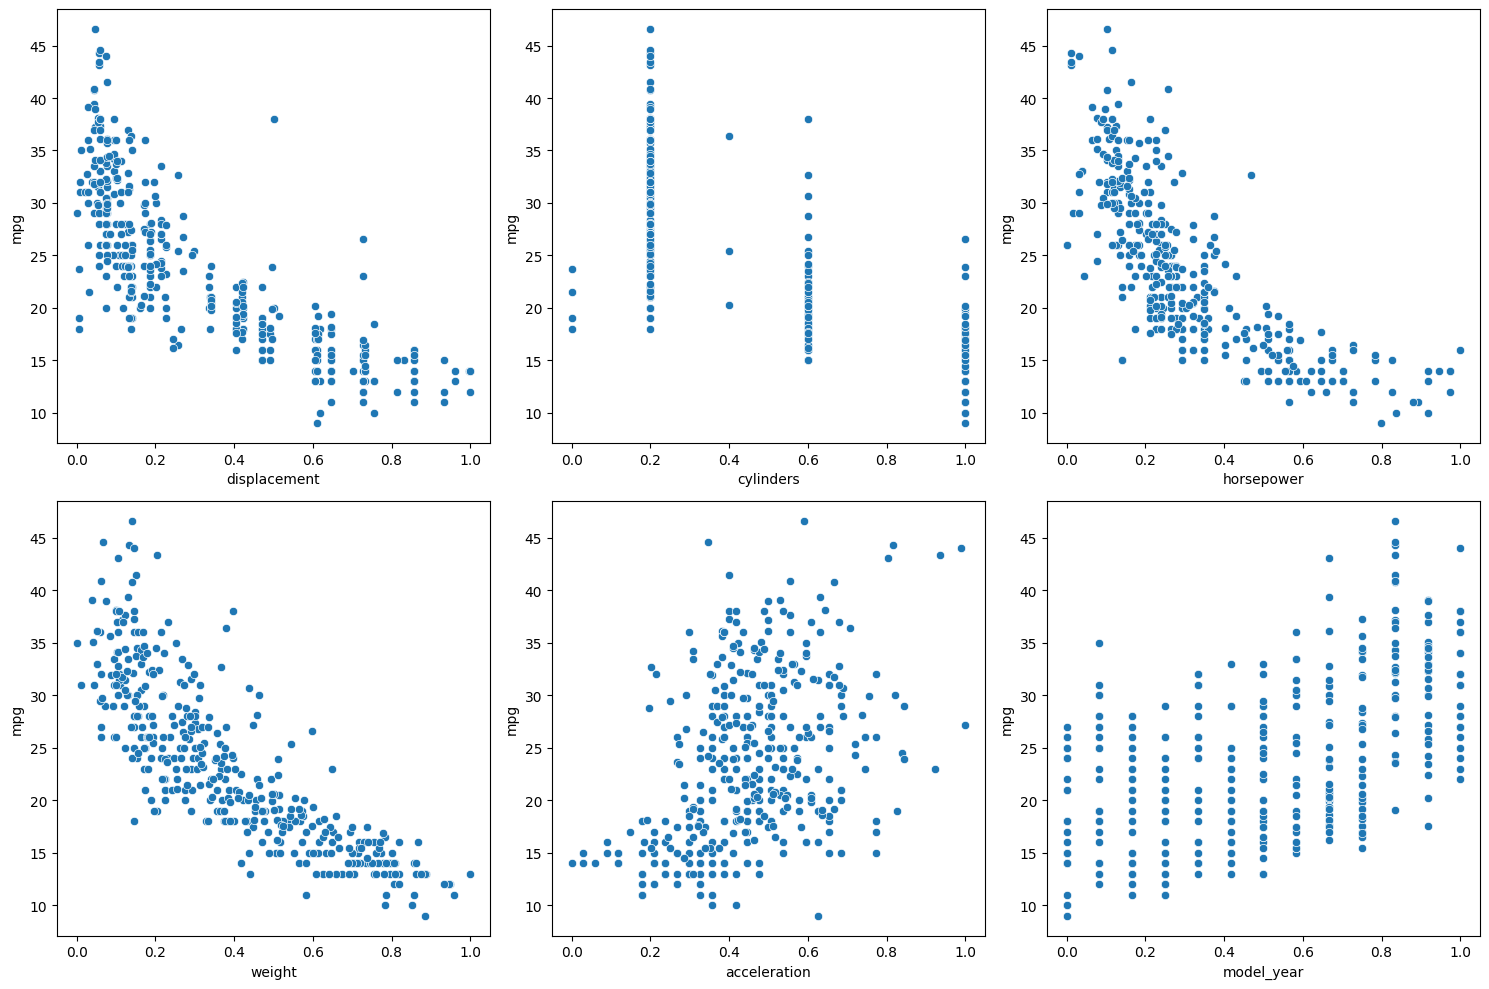

In [7]:
feature_names = df.columns[:-1].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, feature in zip(axes, feature_names):
    sns.scatterplot(data=df, x=feature, y='mpg', ax=ax)
    ax.set_xlabel(feature)
    ax.set_ylabel('mpg')

fig.tight_layout()
plt.show()

### Разбить выборку на обучающую и тестовую.

> Из датафреймов обучающей и тестовой выборки необходимо временно убрать категориальные признаки (исходные датафреймы сохранить для 2 этапа).

In [8]:
from sklearn.model_selection import train_test_split

# Разбиваем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_num = X_train.drop(columns='origin', errors='ignore')
X_test_num = X_test.drop(columns='origin', errors='ignore')

## Регрессия МНК

### Обучить модель линейной регрессии `LinearRegression`

In [9]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_num, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Вывести метрики $MSE$, $MAE$ и $R^2$ на тестовом наборе

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Предсказания на тесте
y_pred = lr_model.predict(X_test_num)

# Метрики
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.6f}')
print(f'MAE: {mae:.6f}')
print(f'R²: {r2:.6f}')

MSE: 9.440068
MAE: 2.466781
R²: 0.824425


### Вывести `model.coef_` и `model.intercept_`

In [11]:
print('Коэффициенты (coef_):')
for feature, coef in zip(X_train_num.columns, lr_model.coef_.flatten()):
    print(f'  {feature}: {coef:.6f}')

print(f'\nСвободный член (intercept_): {float(lr_model.intercept_[0]):.6f}')

Коэффициенты (coef_):
  displacement: 0.620579
  cylinders: 0.345246
  horsepower: 0.533275
  weight: -24.843136
  acceleration: 1.354317
  model_year: 9.616378

Свободный член (intercept_): 27.120198


### Построить график (`barh`) с важностью коэффициентов при соответствующих признаках

(сверху вниз расположены коэффициенты по убыванию, а названия соответствующих признаков подписаны по вертикальной оси)

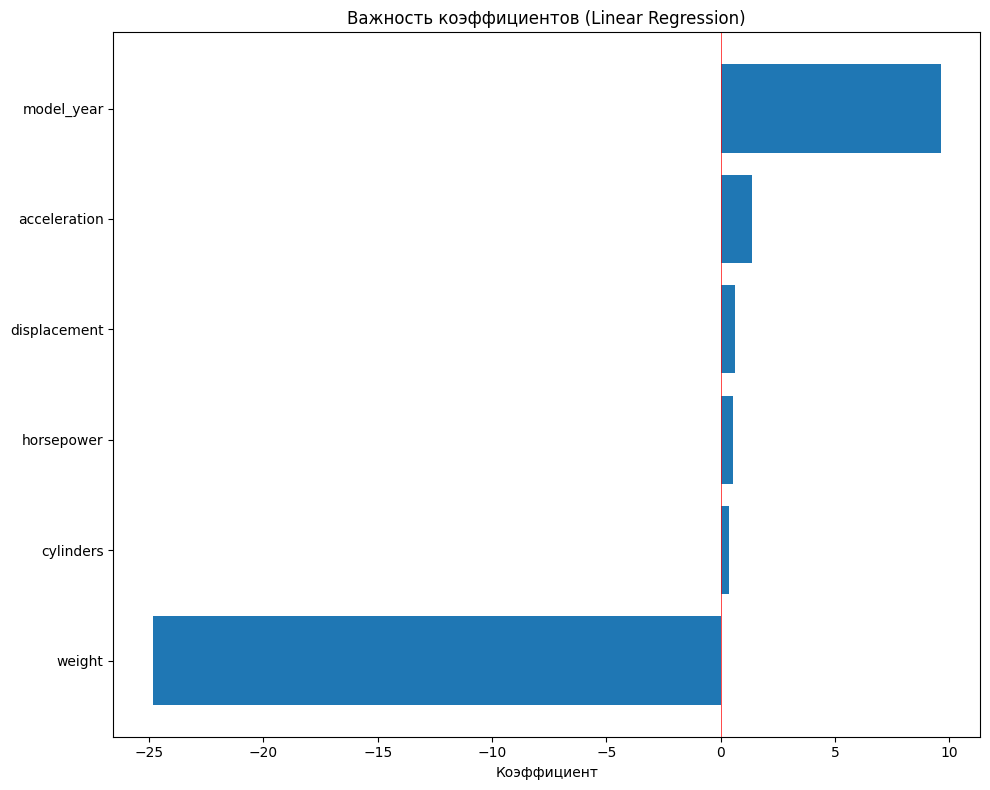

In [12]:
# Создаем DataFrame с коэффициентами
coef_df = pd.DataFrame({
    'feature': X_train_num.columns.tolist(),
    'coefficient': lr_model.coef_.flatten()
})

# Сортируем по убыванию коэффициентов
coef_df = coef_df.sort_values('coefficient', ascending=True)

# График
plt.figure(figsize=(10, 8))
plt.barh(coef_df['feature'], coef_df['coefficient'])
plt.xlabel('Коэффициент')
plt.title('Важность коэффициентов (Linear Regression)')
plt.axvline(x=0, color='red', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

## Для каждого вида регрессии

(`Ridge`, `LASSO`, `Elastic Net`, [KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) и какой-нибудь tree-based модели регрессии)

### С использованием `GridSearchCV` осуществить подбор параметров регуляризации (`alpha` для `Ridge` и `LASSO`, `alpha` и `l1_ratio` для `Elastic Net`) и гиперпараметров (`n_neighbors` для `KNeighborsRegressor`; как минимум `max_depth` для tree-based моделей регрессии)

In [13]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

Ridge Regression

In [14]:
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
ridge_gs = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_gs.fit(X_train_num, y_train)
print(f'Ridge best params: {ridge_gs.best_params_}')
print(f'Ridge best score: {ridge_gs.best_score_:.4f}')
print(f'Коэффициенты: {ridge_gs.best_estimator_.coef_}')
print(f'Свободный член: {ridge_gs.best_estimator_.intercept_}')

Ridge best params: {'alpha': 0.1}
Ridge best score: 0.7943
Коэффициенты: [ -0.11438868   0.22417187  -0.15274566 -23.47557813   0.86783758
   9.50164782]
Свободный член: [27.38118223]


LASSO Regression

In [15]:
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}
lasso_gs = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_gs.fit(X_train_num, y_train)
print(f'LASSO best params: {lasso_gs.best_params_}')
print(f'LASSO best score: {lasso_gs.best_score_:.4f}')
print(f'Коэффициенты: {lasso_gs.best_estimator_.coef_}')
print(f'Свободный член: {lasso_gs.best_estimator_.intercept_}')

LASSO best params: {'alpha': 0.01}
LASSO best score: 0.7971
Коэффициенты: [ -0.          -0.          -0.         -23.4794993    0.52364099
   9.46589584]
Свободный член: [27.58233575]


Elastic Net

In [16]:
elastic_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0], 'l1_ratio': [0.1, 0.5, 0.9]}
elastic_gs = GridSearchCV(ElasticNet(max_iter=10000), elastic_params, cv=5, scoring='r2', n_jobs=-1)
elastic_gs.fit(X_train_num, y_train)
print(f'Elastic Net best params: {elastic_gs.best_params_}')
print(f'Elastic Net best score: {elastic_gs.best_score_:.4f}')
print(f'Коэффициенты: {elastic_gs.best_estimator_.coef_}')
print(f'Свободный член: {elastic_gs.best_estimator_.intercept_}')

Elastic Net best params: {'alpha': 0.01, 'l1_ratio': 0.9}
Elastic Net best score: 0.7952
Коэффициенты: [ -1.28297928  -0.25157086  -1.07782953 -20.92810559   0.
   9.23921618]
Свободный член: [27.82256645]


KNN Regressor

In [17]:
knn_params = {'n_neighbors': [3, 5, 7, 10, 15, 20]}
knn_gs = GridSearchCV(KNeighborsRegressor(), knn_params, cv=5, scoring='r2', n_jobs=-1)
knn_gs.fit(X_train_num, y_train)
print(f'KNN best params: {knn_gs.best_params_}')
print(f'KNN best score: {knn_gs.best_score_:.4f}')

KNN best params: {'n_neighbors': 10}
KNN best score: 0.8431


Random Forest Regressor

In [18]:
rf_params = {'max_depth': [5, 10, 15, 20, None], 'n_estimators': [50, 100, 200]}
rf_gs = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=5, scoring='r2', n_jobs=-1)
rf_gs.fit(X_train_num, y_train.values.ravel())
print(f'Random Forest best params: {rf_gs.best_params_}')
print(f'Random Forest best score: {rf_gs.best_score_:.4f}')

Random Forest best params: {'max_depth': 20, 'n_estimators': 200}
Random Forest best score: 0.8476


Находим лучшую модель по R² на тесте

In [19]:
best_models_no_cat = {
    'LinearRegression': lr_model,
    'Ridge': ridge_gs.best_estimator_,
    'LASSO': lasso_gs.best_estimator_,
    'ElasticNet': elastic_gs.best_estimator_,
    'KNN': knn_gs.best_estimator_,
    'RandomForest': rf_gs.best_estimator_
}

best_r2 = -float('inf')
best_model_name = None

for name, model in best_models_no_cat.items():
    y_pred = model.predict(X_test_num)
    r2 = r2_score(y_test, y_pred)
    print(f'{name}: R² = {r2:.4f}')
    if r2 > best_r2:
        best_r2 = r2
        best_model_name = name

print(f'Лучшая модель (без категориальных): {best_model_name} с R² = {best_r2:.4f}')

LinearRegression: R² = 0.8244
Ridge: R² = 0.8249
LASSO: R² = 0.8262
ElasticNet: R² = 0.8270
KNN: R² = 0.8855
RandomForest: R² = 0.9065
Лучшая модель (без категориальных): RandomForest с R² = 0.9065


### Вывести значения гиперпараметров, коэффициенты регрессии (`model.coef_` и `model.intercept_`) и значения метрик на тестовом наборе для наилучшей модели ($MSE$, $MAE$ и $R^2$)

Ранее уже были выведены значения гиперпараметров и коэффициенты регрессии лучших моделей. Посчитаем только метрики.

In [20]:
model = best_models_no_cat[best_model_name]
y_pred = model.predict(X_test_num)

print(f'MSE: {mean_squared_error(y_test, y_pred):.6f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.6f}')
print(f'R²: {r2_score(y_test, y_pred):.6f}')

MSE: 5.026430
MAE: 1.645137
R²: 0.906514


### Построить график (`barh`) с важностью коэффициентов при соответствующих признаках 

(сверху вниз расположены коэффициенты по убыванию, а названия соответствующих признаков подписаны по вертикальной оси)

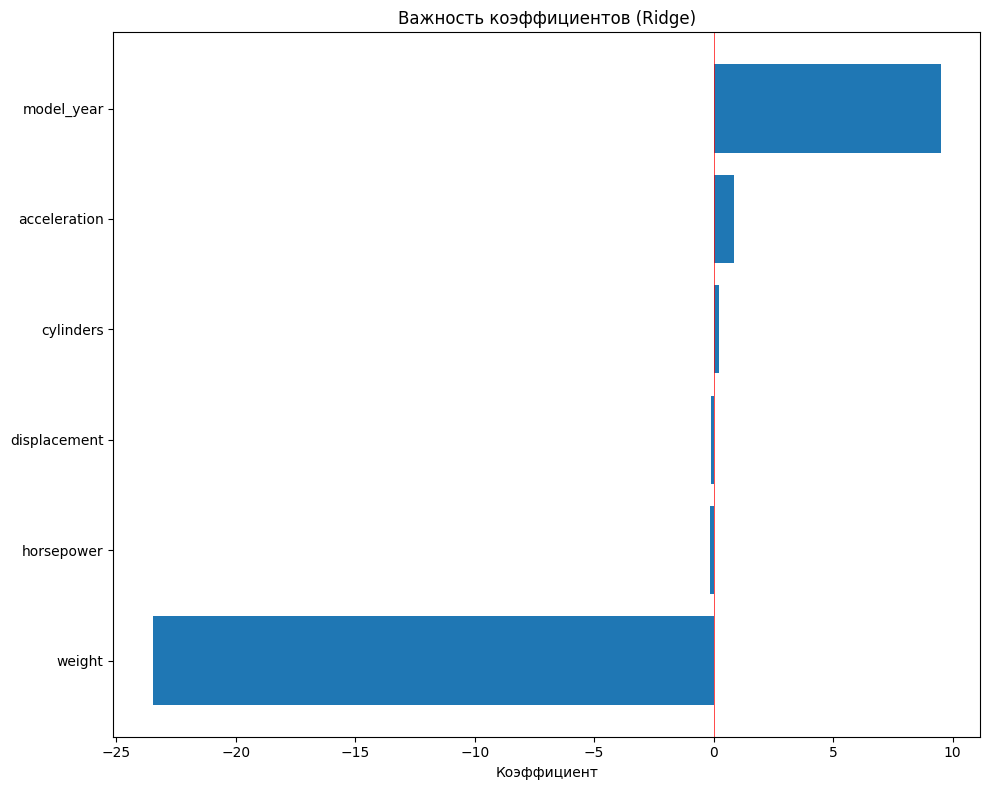

In [21]:
coef_df_ridge = pd.DataFrame({
    'feature': X_train_num.columns.tolist(),
    'coefficient': ridge_gs.best_estimator_.coef_
}).sort_values('coefficient', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(coef_df_ridge['feature'], coef_df_ridge['coefficient'])
plt.xlabel('Коэффициент')
plt.title('Важность коэффициентов (Ridge)')
plt.axvline(x=0, color='red', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

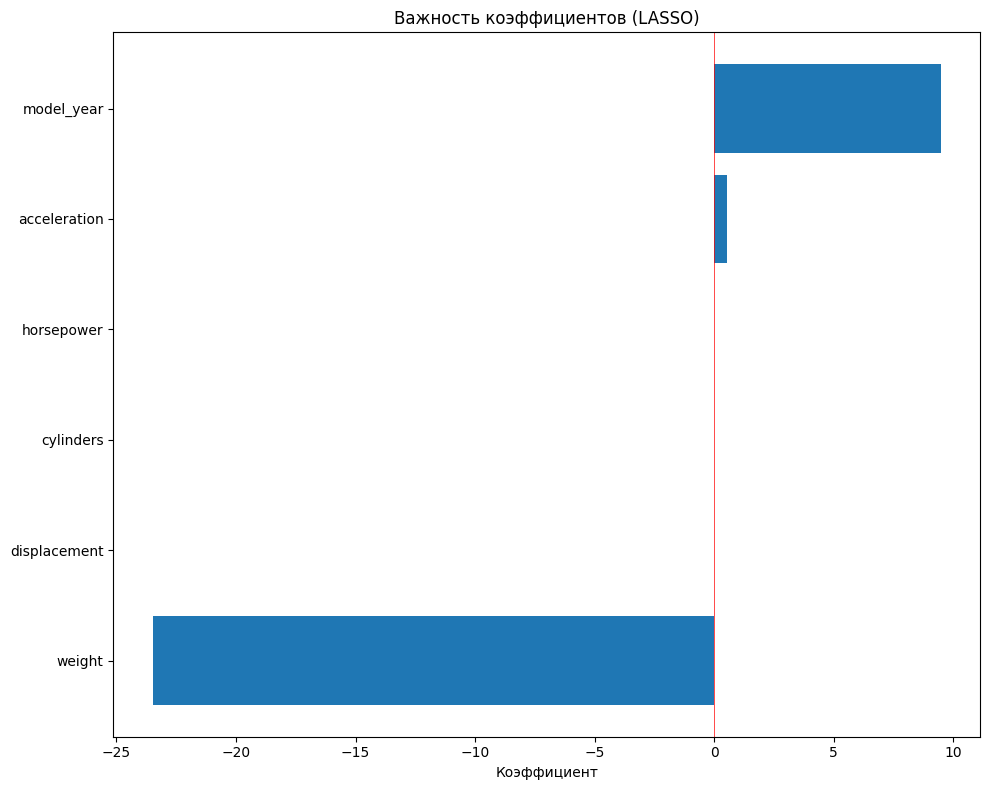

In [22]:
coef_df_lasso = pd.DataFrame({
    'feature': X_train_num.columns.tolist(),
    'coefficient': lasso_gs.best_estimator_.coef_
}).sort_values('coefficient', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(coef_df_lasso['feature'], coef_df_lasso['coefficient'])
plt.xlabel('Коэффициент')
plt.title('Важность коэффициентов (LASSO)')
plt.axvline(x=0, color='red', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

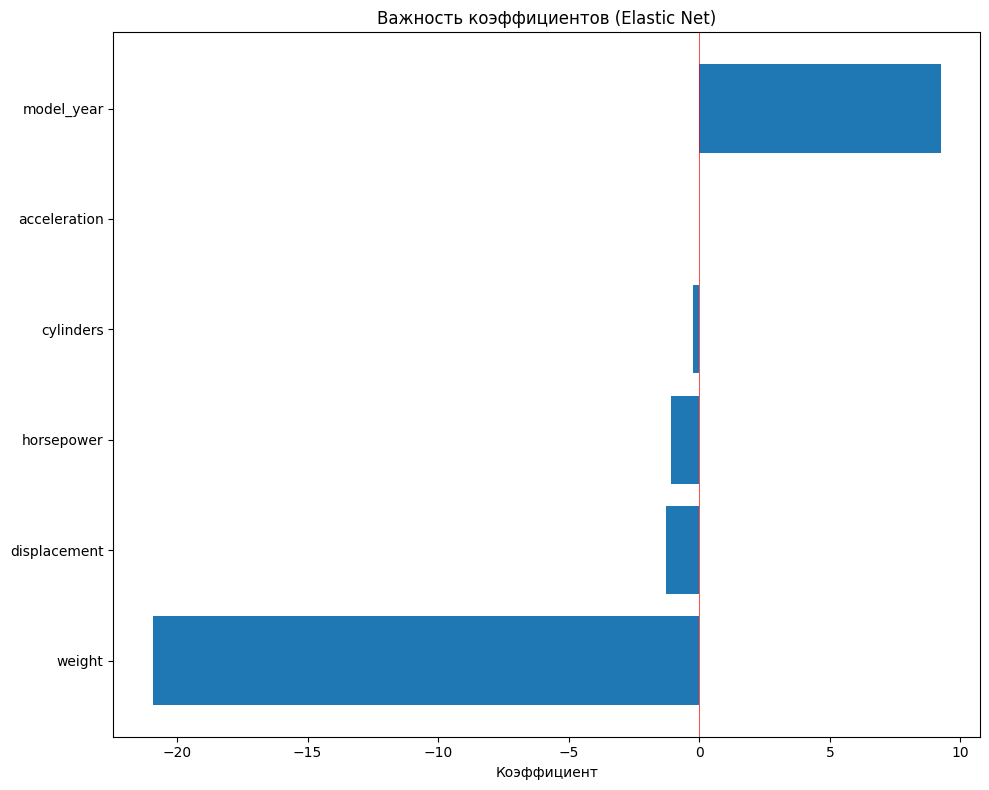

In [23]:
coef_df_elastic = pd.DataFrame({
    'feature': X_train_num.columns.tolist(),
    'coefficient': elastic_gs.best_estimator_.coef_
}).sort_values('coefficient', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(coef_df_elastic['feature'], coef_df_elastic['coefficient'])
plt.xlabel('Коэффициент')
plt.title('Важность коэффициентов (Elastic Net)')
plt.axvline(x=0, color='red', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

## Датасет и подготовка данных, этап 2

### Использовать датафреймы после разбиения на обучающую и тестовую выборки из 1 этапа с категориальными признаками

In [24]:
X_train_cat = X_train
X_test_cat = X_test

print(f'X_train_cat shape: {X_train_cat.shape}')
print(f'X_test_cat shape: {X_test_cat.shape}')
print(f'X_train_num shape: {X_train_num.shape}')
print(f'X_test_num shape: {X_test_num.shape}')

X_train_cat shape: (318, 7)
X_test_cat shape: (80, 7)
X_train_num shape: (318, 6)
X_test_num shape: (80, 6)


### Закодировать категориальные признаки в обучающей и тестовой выборках

In [25]:
X['origin'].value_counts()

origin
1    249
3     79
2     70
Name: count, dtype: int64

In [26]:
X_train_cat = pd.get_dummies(X_train_cat, columns=['origin'], prefix='origin')
X_test_cat = pd.get_dummies(X_test_cat, columns=['origin'], prefix='origin')
X_train_cat.info()

<class 'pandas.DataFrame'>
Index: 318 entries, 3 to 102
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  318 non-null    float64
 1   cylinders     318 non-null    float64
 2   horsepower    318 non-null    float64
 3   weight        318 non-null    float64
 4   acceleration  318 non-null    float64
 5   model_year    318 non-null    float64
 6   origin_1      318 non-null    bool   
 7   origin_2      318 non-null    bool   
 8   origin_3      318 non-null    bool   
dtypes: bool(3), float64(6)
memory usage: 18.3 KB


## Регрессии, этап 2

### Обучить `LinearRegression`, лучшие модели `Ridge`, `LASSO`, `Elastic Net`, `KNeighborsRegressor`, `<tree-based name>` на обучающем наборе с категориальными признаками

Linear Regression

In [27]:
lr_model_cat = LinearRegression()
lr_model_cat.fit(X_train_cat, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Ridge (с лучшими параметрами из этапа 1)

In [28]:
ridge_model_cat = Ridge(alpha=ridge_gs.best_params_['alpha'])
ridge_model_cat.fit(X_train_cat, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


LASSO (с лучшими параметрами из этапа 1)

In [29]:
lasso_model_cat = Lasso(alpha=lasso_gs.best_params_['alpha'], max_iter=10000)
lasso_model_cat.fit(X_train_cat, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


Elastic Net (с лучшими параметрами из этапа 1)

In [30]:
elastic_model_cat = ElasticNet(
    alpha=elastic_gs.best_params_['alpha'],
    l1_ratio=elastic_gs.best_params_['l1_ratio'],
    max_iter=10000
)
elastic_model_cat.fit(X_train_cat, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.01
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.9
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


KNN (с лучшими параметрами из этапа 1)

In [31]:
knn_model_cat = KNeighborsRegressor(n_neighbors=knn_gs.best_params_['n_neighbors'])
knn_model_cat.fit(X_train_cat, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Random Forest (с лучшими параметрами из этапа 1)

In [32]:
rf_model_cat = RandomForestRegressor(
    max_depth=rf_gs.best_params_['max_depth'],
    n_estimators=rf_gs.best_params_['n_estimators'],
    random_state=42
)
rf_model_cat.fit(X_train_cat, y_train.values.ravel())

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Сохраним модели

In [33]:
best_models_cat = {
    'LinearRegression': lr_model_cat,
    'Ridge': ridge_model_cat,
    'LASSO': lasso_model_cat,
    'ElasticNet': elastic_model_cat,
    'KNN': knn_model_cat,
    'RandomForest': rf_model_cat
}

### Вывести значения гиперпараметров, коэффициенты регрессии (`model.coef_` и `model.intercept_`) и значения метрик на тестовом наборе ($MSE$, $MAE$ и $R^2$)

In [34]:
# Функция для вывода метрик
def print_model_metrics_cat(model, model_name):
    y_pred = model.predict(X_test_cat)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f'\n=== {model_name} (с категориальными) ===')
    print(f'MSE: {mse:.6f}')
    print(f'MAE: {mae:.6f}')
    print(f'R²: {r2:.6f}')
    
    if hasattr(model, 'coef_'):
        print(f'Коэффициенты: {model.coef_}')
    if hasattr(model, 'intercept_'):
        intercept = model.intercept_
        print(f'  Свободный член: {float(intercept.flatten()[0]):.6f}')

# Вывод метрик для всех моделей
for name, model in best_models_cat.items():
    print_model_metrics_cat(model, name)


=== LinearRegression (с категориальными) ===
MSE: 8.338657
MAE: 2.288159
R²: 0.844910
Коэффициенты: [[  7.65319985  -0.82831888  -2.67938509 -24.85570897   1.14183757
    9.91163126  -1.87267756   1.07422911   0.79844844]]
  Свободный член: 27.187266

=== Ridge (с категориальными) ===
MSE: 8.343803
MAE: 2.281453
R²: 0.844814
Коэффициенты: [  6.16972997  -0.68254847  -3.02619652 -23.34413187   0.71011973
   9.78354709  -1.83587946   1.02535785   0.81052161]
  Свободный член: 27.362781

=== LASSO (с категориальными) ===
MSE: 8.484173
MAE: 2.285305
R²: 0.842203
Коэффициенты: [  2.63588589   0.          -1.55752301 -22.10099359   0.28777678
   9.66275942  -2.35500845   0.14728227   0.        ]
  Свободный член: 28.124729

=== ElasticNet (с категориальными) ===
MSE: 8.510736
MAE: 2.294158
R²: 0.841709
Коэффициенты: [  0.5791161    0.          -2.27313469 -19.32890577   0.
   9.38858913  -2.38859375   0.0217775    0.        ]
  Свободный член: 28.252777

=== KNN (с категориальными) ===
MSE:

### Сравнить метрики с наличием категориальных признаков и без для каждой из моделей

In [35]:
print('Сравнение метрик R²:')
print('-' * 60)
print(f'{"Модель":<20} | {"Без кат.":<12} | {"С кат.":<12} | {"Разница":<12}')
print('-' * 60)

for name in best_models_no_cat.keys():
    y_pred_no_cat = best_models_no_cat[name].predict(X_test_num)
    y_pred_cat = best_models_cat[name].predict(X_test_cat)
    
    r2_no_cat = r2_score(y_test, y_pred_no_cat)
    r2_cat = r2_score(y_test, y_pred_cat)
    diff = r2_cat - r2_no_cat
    
    print(f'{name:<20} | {r2_no_cat:<12.4f} | {r2_cat:<12.4f} | {diff:<+12.4f}')

print('-' * 60)

Сравнение метрик R²:
------------------------------------------------------------
Модель               | Без кат.     | С кат.       | Разница     
------------------------------------------------------------
LinearRegression     | 0.8244       | 0.8449       | +0.0205     
Ridge                | 0.8249       | 0.8448       | +0.0199     
LASSO                | 0.8262       | 0.8422       | +0.0160     
ElasticNet           | 0.8270       | 0.8417       | +0.0147     
KNN                  | 0.8855       | 0.8946       | +0.0091     
RandomForest         | 0.9065       | 0.9118       | +0.0053     
------------------------------------------------------------


Добавление категориального признака 'origin' (закодированного через One-Hot Encoding) положительно сказалось на качестве всех моделей: R² увеличился в диапазоне от +0.0053 до +0.0205. Наибольший прирост показали линейные модели (Linear Regression, Ridge, LASSO, ElasticNet) — в среднем +0.018, что объясняется тем, что они смогли учесть влияние происхождения автомобиля (США, Европа, Япония) как отдельный фактор. Random Forest и KNN продемонстрировали меньший прирост (+0.007 в среднем), поскольку деревья решений лучше работают с исходными числовыми признаками и менее чувствительны к добавлению категориальных переменных. Наилучший результат показала Random Forest с R² = 0.9118, что означает объяснение 91% дисперсии целевой переменной.

### Выбрать лучшую модель

In [36]:
best_model = best_models_cat['RandomForest']

### Построить график (`barh`) с важностью коэффициентов при соответствующих признаках

(сверху вниз расположены коэффициенты по убыванию, а названия соответствующих признаков подписаны по вертикальной оси)

Для Random Forest используем feature_importances_

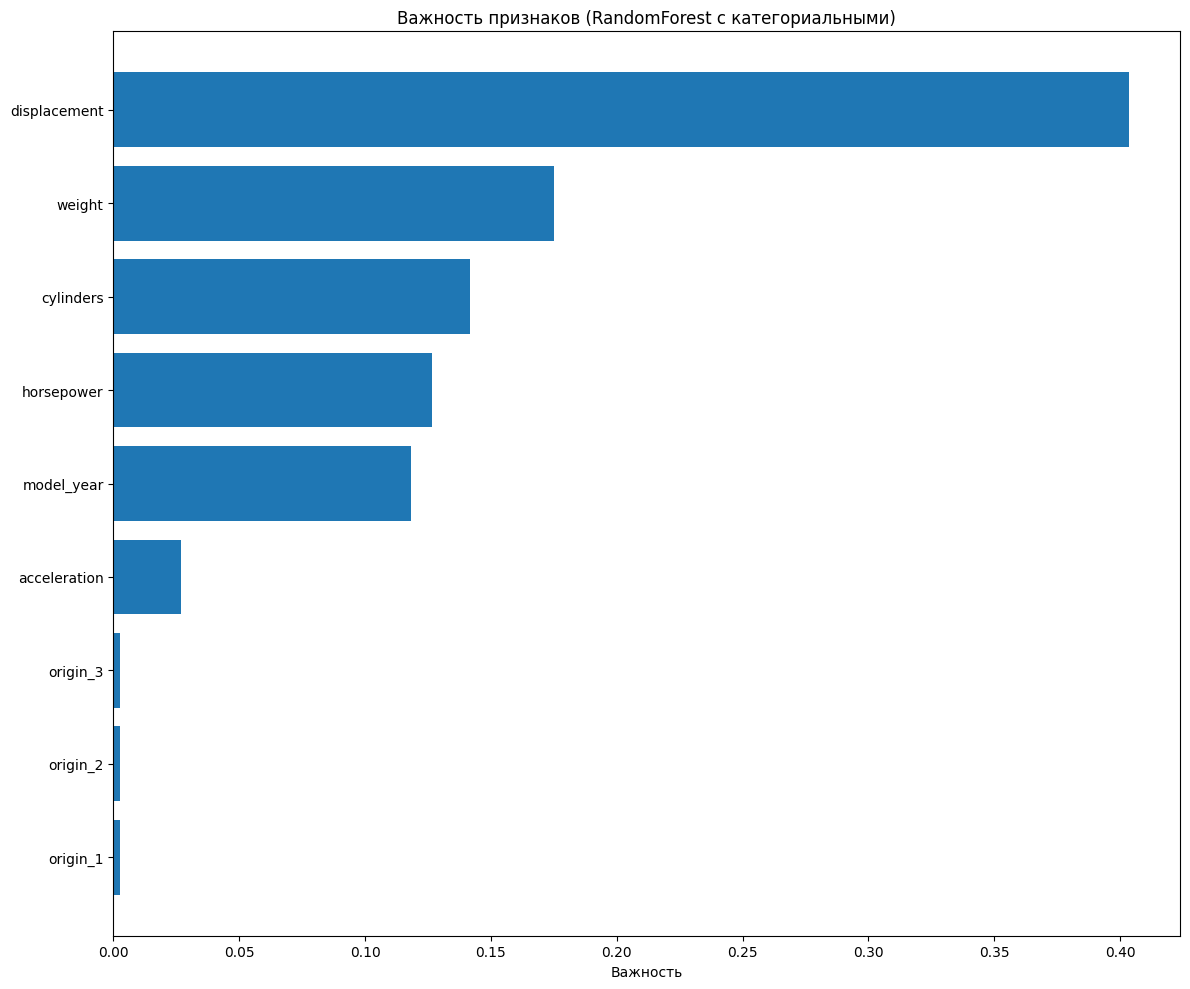

In [37]:
importances_df = pd.DataFrame({
    'feature': X_train_cat.columns.tolist(),
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(12, 10))
plt.barh(importances_df['feature'], importances_df['importance'])
plt.xlabel('Важность')
plt.title(f'Важность признаков (RandomForest с категориальными)')
plt.tight_layout()
plt.show()

### Осуществить фильтрацию признаков:
+ с использованием `Recursive Feature Elimination` или [RFECV](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFECV.html(`RFE` с кросс-валидацией)
+ с использованием `Sequential Feature Selector` (`forward` или `backward` в зависимости от количества признаков или по желанию)
+ с использованием любой другой процедуры по желани

 В качестве модели-оценщика выбрать любую модель (`LinearRegression`, `SelectKBest` [см. [Примечание](#примечание)], tree-based модели`DecisionTreeRegressor`, `RandomForestRegressor` и др.)
 
 Выбрать лучшую процедуру фильтрации.

RFECV с LinearRegression

In [38]:
from sklearn.feature_selection import RFECV, SequentialFeatureSelector

rfe_model = LinearRegression()
rfecv = RFECV(estimator=rfe_model, step=1, cv=5, scoring='r2', n_jobs=-1)
rfecv.fit(X_train_cat, y_train)

print(f'Оптимальное количество признаков: {rfecv.n_features_}')

Оптимальное количество признаков: 5


Обучаем модель на отобранных признаках

In [39]:
X_train_rfe = rfecv.transform(X_train_cat)
X_test_rfe = rfecv.transform(X_test_cat)

rf_rfe = RandomForestRegressor(
    max_depth=rf_gs.best_params_['max_depth'],
    n_estimators=rf_gs.best_params_['n_estimators'],
    random_state=42
)
rf_rfe.fit(X_train_rfe, y_train.values.ravel())

y_pred_rfe = rf_rfe.predict(X_test_rfe)
r2_rfe = r2_score(y_test, y_pred_rfe)
mse_rfe = mean_squared_error(y_test, y_pred_rfe)
mae_rfe = mean_absolute_error(y_test, y_pred_rfe)

print(f'Метрики RFECV + LinearRegression:')
print(f'R²: {r2_rfe:.4f}')
print(f'MSE: {mse_rfe:.6f}')
print(f'MAE: {mae_rfe:.6f}')

Метрики RFECV + LinearRegression:
R²: 0.9124
MSE: 4.708133
MAE: 1.603112


Sequential Feature Selector (backward)

In [40]:
sfs_model = RandomForestRegressor(
    max_depth=rf_gs.best_params_['max_depth'],
    n_estimators=rf_gs.best_params_['n_estimators'],
    random_state=42
)
sfs = SequentialFeatureSelector(sfs_model, n_features_to_select='auto', direction='backward', cv=5, n_jobs=-1)
sfs.fit(X_train_cat, y_train)
print(f"Осталось признаков: {sfs.n_features_to_select_}")

Осталось признаков: 5


Обучаем модель на отобранных признаках

In [41]:
X_train_sfs = sfs.transform(X_train_cat)
X_test_sfs = sfs.transform(X_test_cat)

rf_sfs = RandomForestRegressor(
    max_depth=rf_gs.best_params_['max_depth'],
    n_estimators=rf_gs.best_params_['n_estimators'],
    random_state=42
)
rf_sfs.fit(X_train_sfs, y_train.values.ravel())

y_pred_sfs = rf_sfs.predict(X_test_sfs)
r2_sfs = r2_score(y_test, y_pred_sfs)
mse_sfs = mean_squared_error(y_test, y_pred_sfs)
mae_sfs = mean_absolute_error(y_test, y_pred_sfs)

print(f'Метрики SFS + RandomForest:')
print(f'R²: {r2_sfs:.4f}')
print(f'MSE: {mse_sfs:.6f}')
print(f'MAE: {mae_sfs:.6f}')

Метрики SFS + RandomForest:
R²: 0.9138
MSE: 4.635872
MAE: 1.702481


 Выбрать лучшую процедуру фильтрации.

SFS отбирает признаки итеративно, оценивая вклад каждого на каждом шаге, что позволило RandomForest лучше раскрыть взаимосвязи в данных. RFECV, хотя и показал лучшую MAE, уступает по основным метрикам (R² и MSE).

###  Построить график (`barh`) с важностью коэффициентов при соответствующих признаках

(сверху вниз расположены коэффициенты по убыванию, а названия соответствующих признаков подписаны по вертикальной оси)

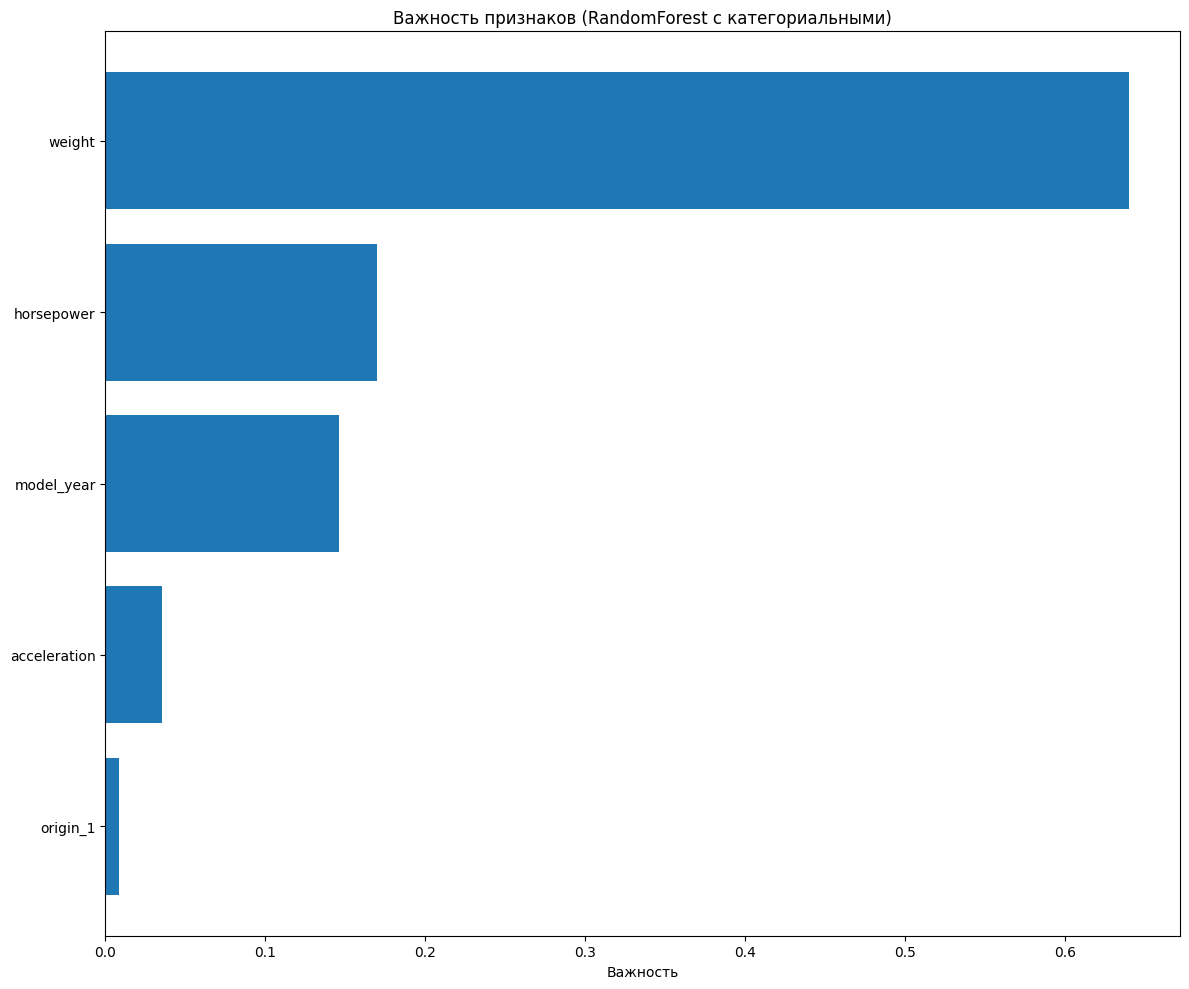

In [42]:
importances_df = pd.DataFrame({
    'feature': X_train_cat.columns[sfs.support_].tolist(),
    'importance': rf_sfs.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(12, 10))
plt.barh(importances_df['feature'], importances_df['importance'])
plt.xlabel('Важность')
plt.title(f'Важность признаков (RandomForest с категориальными)')
plt.tight_layout()
plt.show()

## Сделать вывод

### Лучший регрессор, обученный на данных без категориальных признаков 
(значения метрик на тестовом наборе)

In [43]:
results_no_cat = []

for name, model in best_models_no_cat.items():
    y_pred = model.predict(X_test_num)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mse ** 0.5
    
    results_no_cat.append({
        'Модель': name,
        'R²': r2,
        'MSE': mse,
        'MAE': mae,
        'RMSE': rmse
    })
    
results_df = pd.DataFrame(results_no_cat).sort_values('R²', ascending=False)
results_df = results_df.reset_index(drop=True)

results_df

,Модель,R²,MSE,MAE,RMSE
0,RandomForest,0.906514,5.026430,1.645137,2.241970
1,KNN,0.885540,6.154082,1.864250,2.480742
2,ElasticNet,0.826970,9.303191,2.437675,3.050113
3,LASSO,0.826242,9.342364,2.445016,3.056528
4,Ridge,0.824908,9.414076,2.462263,3.068237
5,LinearRegression,0.824425,9.440068,2.466781,3.072469


Наилучший результат показала модель Random Forest (R²=0.9065), значительно превзойдя линейные модели (R²≈0.82–0.83) и KNN (R²=0.886). Это свидетельствует о нелинейном характере зависимостей в данных: ансамбли деревьев решений лучше улавливают сложные взаимосвязи между признаками и целевой переменной. Среди линейных моделей разница минимальна, а регуляризация (Ridge, LASSO, ElasticNet) не дала существенного улучшения, что указывает на отсутствие сильной мультиколлинеарности. Тем не менее, все модели работают хорошо — даже «худшие» из них объясняют более 82% дисперсии MPG.

### Лучший регрессор, обученный на данных с категориальными признаками 
(значения метрик на тестовом наборе)

In [44]:
results_cat = []

for name, model in best_models_cat.items():
    y_pred = model.predict(X_test_cat)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mse ** 0.5
    
    results_cat.append({
        'Model': name,
        'R2': r2,
        'MSE': mse,
        'MAE': mae,
        'RMSE': rmse
    })

# Сортировка по R2
results_df = pd.DataFrame(results_cat).sort_values('R2', ascending=False)
results_df = results_df.reset_index(drop=True)

results_df

,Model,R2,MSE,MAE,RMSE
0,RandomForest,0.911816,4.741316,1.576806,2.177456
1,KNN,0.894601,5.666955,1.808500,2.380537
2,LinearRegression,0.844910,8.338657,2.288159,2.887673
3,Ridge,0.844814,8.343803,2.281453,2.888564
4,LASSO,0.842203,8.484173,2.285305,2.912760
5,ElasticNet,0.841709,8.510736,2.294158,2.917317


Наилучший результат показала модель Random Forest (R²=0.9118), превзойдя линейные модели (R²≈0.84) и KNN (R²=0.895). Добавление категориального признака `origin` улучшило качество всех моделей: прирост R² составил от +0.005 (Random Forest) до +0.020 (линейные модели). Линейные модели с регуляризацией и без показали схожие результаты, что говорит об отсутствии сильной мультиколлинеарности. Random Forest остаётся оптимальным выбором для данного датасета — она объясняет 91% дисперсии и имеет наименьшую ошибку предсказания (RMSE=2.18).

### Вывод о результатах использования процедуры фильтрации признаков 
(лучше или хуже &ndash; значения метрик)

In [45]:
metrics_df = pd.DataFrame({
    'Метод отбора': ['RFECV', 'SFS'],
    'R²': [r2_rfe, r2_sfs],
    'MSE': [mse_rfe, mse_sfs],
    'MAE': [mae_rfe, mae_sfs],
    'RMSE': [mse_rfe ** 0.5, mse_sfs ** 0.5]
}).sort_values('R²', ascending=False).reset_index(drop=True)

metrics_df

,Метод отбора,R²,MSE,MAE,RMSE
0,SFS,0.913778,4.635872,1.702481,2.153107
1,RFECV,0.912434,4.708133,1.603112,2.169823


Обе процедуры отбора признаков показали сопоставимые результаты: SFS (R²=0.9138) незначительно превзошёл RFECV (R²=0.9124) по основным метрикам (R² и MSE), тогда как RFECV показал лучшую MAE (1.60 против 1.70). Разница между методами минимальна (ΔR²=0.0013), что говорит о том, что оба подхода успешно выявили информативный набор признаков. SFS был выбран как лучший метод, поскольку он обеспечивает чуть более высокую объясняющую способность модели (R²) и меньшую среднеквадратичную ошибку (MSE), что важнее для задач прогнозирования.